In [1]:
# some modules to help us with linear algebra and plotting
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Start with our simple example

Let's start with $f(x) = x^2$:

In [2]:
# make our x array
x = np.linspace(-4, 4, 801)

In [3]:
# f(x) = x^2
def f(x):
    return x**2

# derivative of x^2 is 2x
def f_prime(x):
    return 2*x

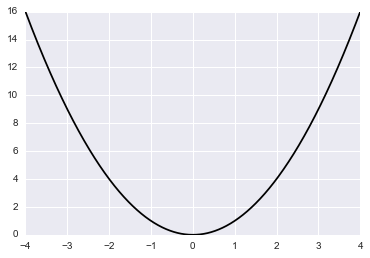

In [4]:
# take a look at the curve
plt.plot(x, f(x), c='black')
sns.despine();

Let's assume we start at the top of the curve, at x = -4, and want to get down to x=0. 

In [5]:
# starting position on the curve
x_start = -4.0

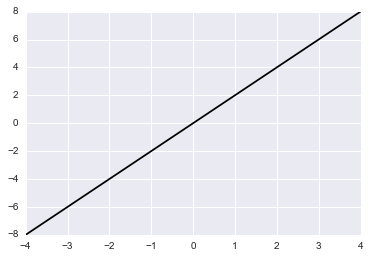

In [6]:
# looking at the values of the derivative, for each value of x. 
# we see the greatest change at the tops of the curve, namely 4 and -4
plt.plot(x, f_prime(x), c='black');

In [7]:
# learning rate
alpha = 0.2

In this algorithm, alpha is known as the "learning rate", and all it does is keep us from taking steps that are too aggressive, where we could shoot past the minimum.

In [8]:
# let's take our first step!
step1 = alpha*f_prime(x_start)

In [9]:
# our new value of x is just the previous value, minus the step
next_x = x_start - step1

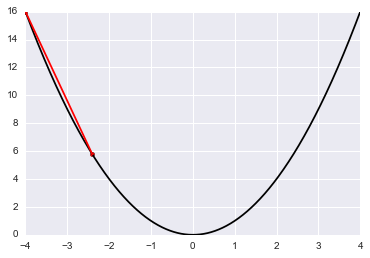

In [10]:
# take a look at the step we took, with respect to the curve
plt.plot(x, f(x), c='black')
plt.scatter([x_start, next_x], [f(x_start), f(next_x)], c='red')
plt.plot([x_start, next_x], [f(x_start), f(next_x)], c='red')
plt.xlim((-4, 4))
plt.ylim((0, 16))
sns.despine();

Here we can see that we took a pretty big step towards the minimum, just as we'd like. 

Let's take another step:

In [11]:
another_x = next_x - alpha*f_prime(next_x)

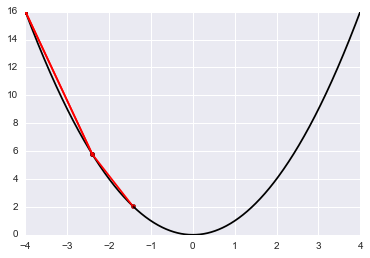

In [12]:
# take a look at the combination of the two steps we've taken
plt.plot(x, f(x), c='black')
plt.plot([x_start, next_x], [f(x_start), f(next_x)], c='red')
plt.scatter([x_start, next_x], [f(x_start), f(next_x)], c='red')
plt.plot([x_start, next_x, another_x], [f(x_start), f(next_x), f(another_x)], c='red')
plt.scatter([x_start, next_x, another_x], [f(x_start), f(next_x), f(another_x)], c='red')
plt.xlim((-4, 4))
plt.ylim((0, 16))
sns.despine();

At this point, we've taken two steps in our Gradient Descent, and we've gone from x=-4 all the way to x=-1.44. Every additional step we take is going to give us smaller and smaller returns, so instead of writing out each additional step, let's do this programatically. 

In [13]:
# how many steps we're going to take in our Descent
num_steps = 101

# hold our steps, including our initial starting position
x_steps = [x_start]

# do num_steps iterations
for i in xrange(num_steps):
    prev_x = x_steps[i]
    new_x = prev_x - alpha*f_prime(prev_x)
    x_steps.append(new_x)

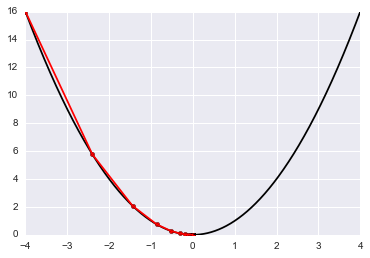

In [14]:
# plot the gradient descent as we go down the curve
plt.plot(x, f(x), c='black')
plt.plot(x_steps, [f(xi) for xi in x_steps], c='red')
plt.scatter(x_steps, [f(xi) for xi in x_steps], c='red')
plt.xlim((-4, 4))
plt.ylim((0, 16))
sns.despine();

In [15]:
# check the size of the derivative when we finished the iteration
print 'gradient at the end of our interations:', x_steps[-1]

# it's zero, for all intensive purposes
print 'Is the derivative effectively equal to zero at the bottom?', np.isclose(x_steps[-1], 0.0)

gradient at the end of our interations: -1.5679646964e-22
Is the derivative effectively equal to zero at the bottom? True
